In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter
import seaborn as sns
import cv2
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from skimage.feature import hog
from skimage import exposure
import kagglehub

# Download dataset
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

c:\Users\aakak\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 612M/612M [03:30<00:00, 3.04MB/s] 

Extracting files...


In [3]:
# Set paths and constants
TRAIN_DIR   = os.path.join(path, "Train")
TEST_DIR    = os.path.join(path, "Test")
TEST_CSV    = os.path.join(path, "Test.csv")

NUM_CLASSES = 43
CLASS_NAMES = {
    0:'Speed limit (20)',    1:'Speed limit (30)',   2:'Speed limit (50)',
    3:'Speed limit (60)',    4:'Speed limit (70)',   5:'Speed limit (80)',
    6:'End speed limit(80)', 7:'Speed limit (100)',  8:'Speed limit (120)',
    9:'No passing',         10:'No passing >3.5t',  11:'Right-of-way',
    12:'Priority road',     13:'Yield',              14:'Stop',
    15:'No vehicles',       16:'No >3.5t vehicles', 17:'No entry',
    18:'General caution',   19:'Danger curve left', 20:'Danger curve right',
    21:'Double curve',      22:'Bumpy road',         23:'Slippery road',
    24:'Road narrows',      25:'Road work',          26:'Traffic signals',
    27:'Pedestrians',       28:'Children crossing',  29:'Bicycles crossing',
    30:'Ice/snow',          31:'Wild animals',       32:'End speed+passing',
    33:'Turn right ahead',  34:'Turn left ahead',    35:'Ahead only',
    36:'Go straight/right', 37:'Go straight/left',   38:'Keep right',
    39:'Keep left',         40:'Roundabout',          41:'End no passing',
    42:'End no passing >3.5t'
}

In [4]:
# Load training and test data
print("Loading training data from folder structure...")
train_paths = []
train_labels = []

for class_id in tqdm(range(NUM_CLASSES), desc="Scanning training class folders"):
    class_folder = os.path.join(TRAIN_DIR, str(class_id))
    if os.path.exists(class_folder):
        for img_file in os.listdir(class_folder):
            if img_file.endswith('.png'):
                img_path = os.path.join(class_folder, img_file)
                train_paths.append(img_path)
                train_labels.append(class_id)

print(f"Training images found: {len(train_paths):,}")

# Load test data
print("\nLoading test data from folder structure...")
test_paths = []
for img_file in os.listdir(TEST_DIR):
    if img_file.endswith('.png'):
        img_path = os.path.join(TEST_DIR, img_file)
        test_paths.append(img_path)

print(f"Test images found: {len(test_paths):,}")

# Load test labels from CSV
test_df = pd.read_csv(TEST_CSV)
test_labels = test_df['ClassId'].values
print(f"Test labels loaded: {len(test_labels)} samples")

Loading training data from folder structure...


Scanning training class folders: 100%|██████████| 43/43 [00:00<00:00, 201.42it/s]

Training images found: 39,209

Loading test data from folder structure...
Test images found: 12,630
Test labels loaded: 12630 samples



CLASS DISTRIBUTION ANALYSIS
Most common class  : Speed limit (50) (2250 images)
Least common class : Speed limit (20) (210 images)


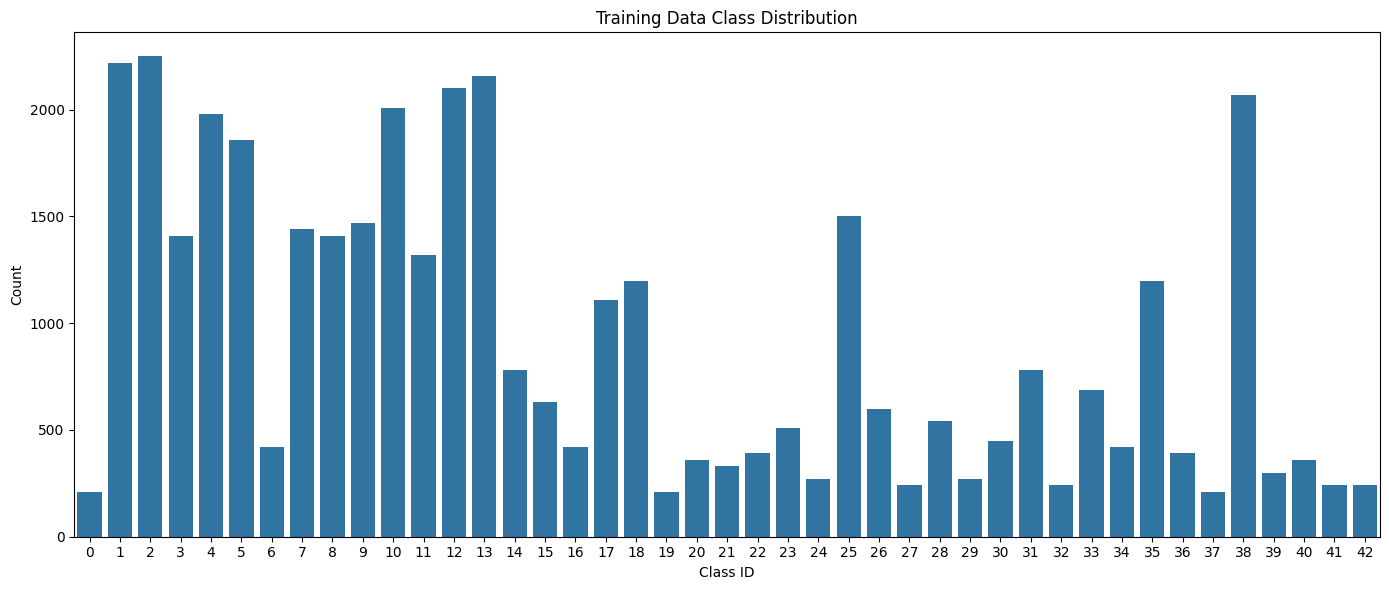

In [5]:
# Check class distribution and visualize
print("\n" + "="*50)
print("CLASS DISTRIBUTION ANALYSIS")
print("="*50)

class_counts = Counter(train_labels)
most_common = class_counts.most_common(1)[0]
least_common = min(class_counts.items(), key=lambda x: x[1])
print(f"Most common class  : {CLASS_NAMES[most_common[0]]} ({most_common[1]} images)")
print(f"Least common class : {CLASS_NAMES[least_common[0]]} ({least_common[1]} images)")

# Visualize class balance
plt.figure(figsize=(14, 6))
sns.barplot(x=list(range(NUM_CLASSES)), y=[class_counts[i] for i in range(NUM_CLASSES)])
plt.xlabel('Class ID')
plt.ylabel('Count')
plt.title('Training Data Class Distribution')
plt.tight_layout()
plt.show()

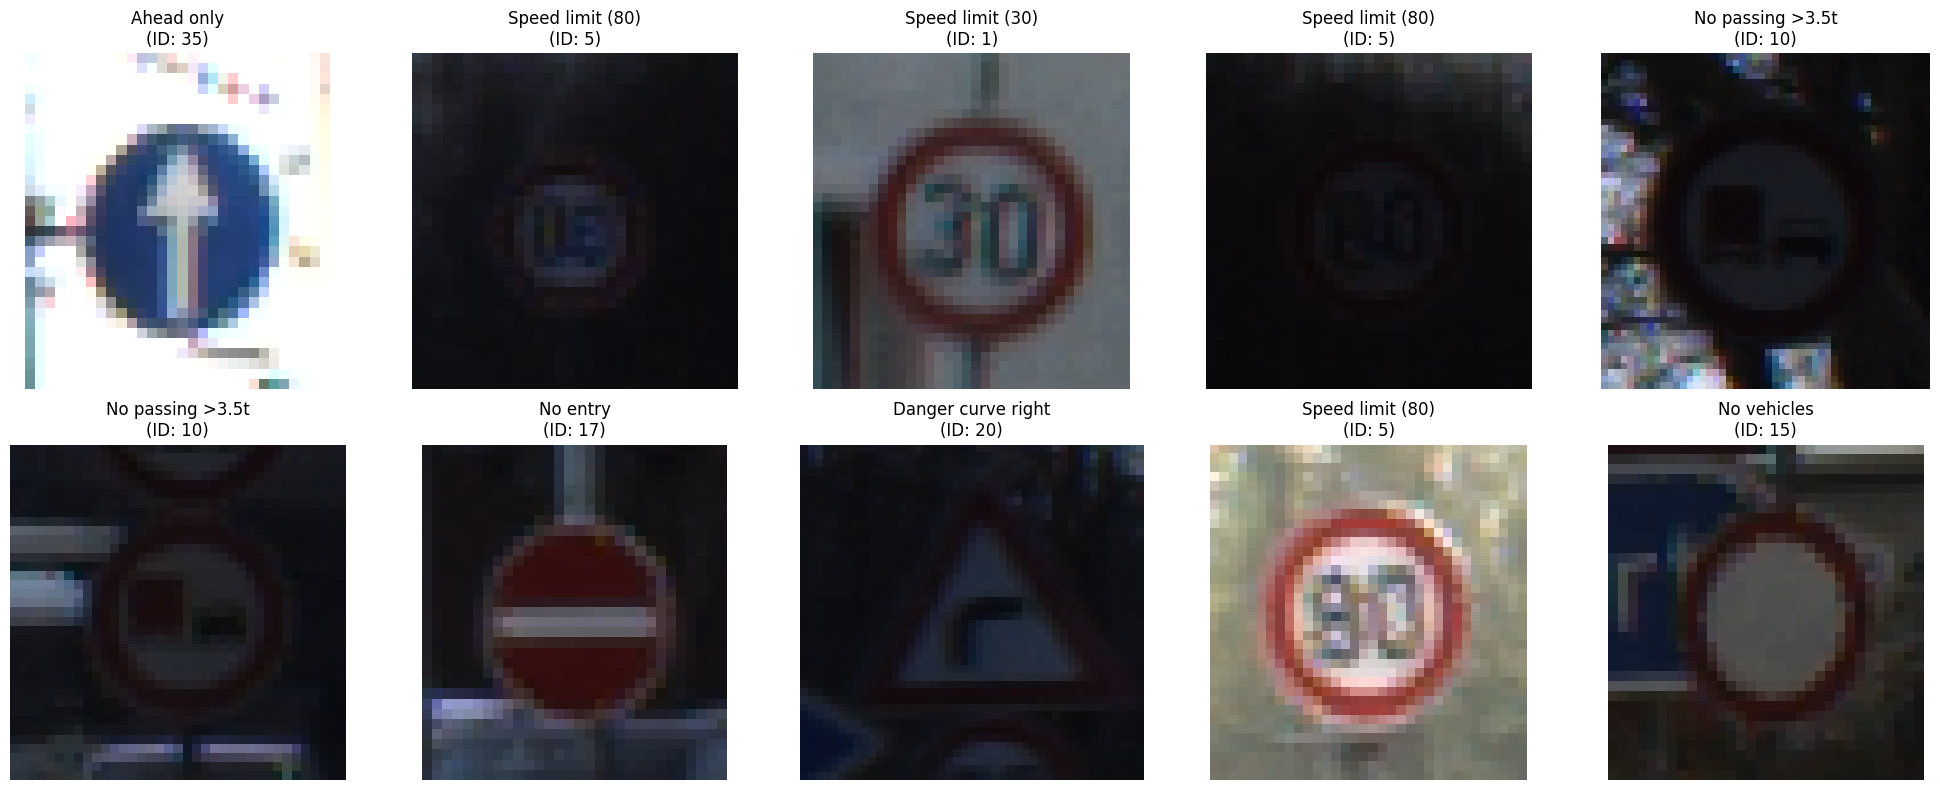

In [8]:
# show sample images
num_samples = 10
indices = np.random.choice(len(train_paths), num_samples, replace=False)

plt.figure(figsize=(20, 8))
for i, idx in enumerate(indices):
    img_path = train_paths[idx]
    label = train_labels[idx]

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"{CLASS_NAMES[label]}\n(ID: {label})")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [9]:
# Calculate pixel statistics for normalization
print("\n" + "="*50)
print("FEATURE EXTRACTION & PREPROCESSING")
print("="*50)
print("\nCalculating dataset statistics...")

sums = np.zeros(3)
sum_sqs = np.zeros(3)
pixel_count = 0

# Sample every 2nd image for speed
for img_path in tqdm(train_paths[::2], desc="Computing pixel statistics"):
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32) / 255.0
    
    sums += np.sum(img, axis=(0, 1))
    sum_sqs += np.sum(img**2, axis=(0, 1))
    pixel_count += img.shape[0] * img.shape[1]

mean = sums / pixel_count
std = np.sqrt((sum_sqs / pixel_count) - (mean**2))

print(f"\nDataset Statistics (RGB):")
print(f"Mean: {mean}")
print(f"Std:  {std}")


FEATURE EXTRACTION & PREPROCESSING

Calculating dataset statistics...


Computing pixel statistics: 100%|██████████| 19605/19605 [02:42<00:00, 120.94it/s]


Dataset Statistics (RGB):
Mean: [0.37542943 0.34546535 0.35496636]
Std:  [0.29935843 0.29276565 0.29924224]



Visualizing HOG features on sample image...


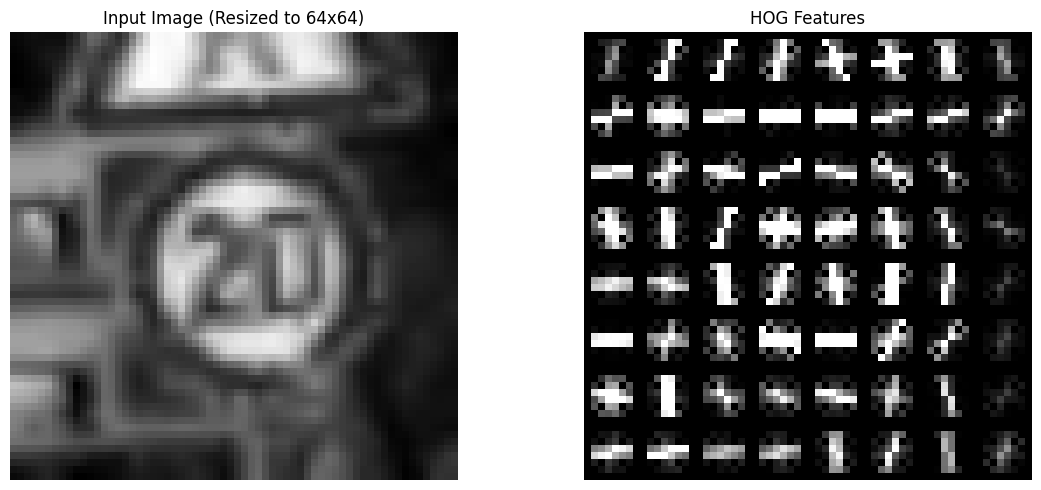

HOG feature vector shape: (512,)


In [14]:
# HOG feature extraction function
def extract_hog(img_path):
    """Extract HOG features from an image"""
    img = cv2.imread(img_path)
    if img is None:
        return None
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img_gray, (64, 64))
    fd = hog(img_resized, orientations=8, pixels_per_cell=(8, 8),
             cells_per_block=(1, 1), visualize=False)
    return fd

# Visualize HOG on sample image
print("\nVisualizing HOG features on sample image...")
sample_img_path = train_paths[1]
img = cv2.imread(sample_img_path)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_resized = cv2.resize(img_gray, (64, 64))

fd, hog_image = hog(img_resized, orientations=8, pixels_per_cell=(8, 8),
                    cells_per_block=(1, 1), visualize=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(img_resized, cmap=plt.cm.gray)
ax1.set_title('Input Image (Resized to 64x64)')
ax1.axis('off')

hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('HOG Features')
ax2.axis('off')
plt.tight_layout()
plt.show()

print(f'HOG feature vector shape: {fd.shape}')

In [15]:
# Extract HOG features for training and test data
print("\nExtracting HOG features for training data...")
train_hog_features = []
for path in tqdm(train_paths, desc="Training HOG extraction"):
    features = extract_hog(path)
    if features is not None:
        train_hog_features.append(features)

print(f"Extracted {len(train_hog_features)} training features")

print("\nExtracting HOG features for test data...")
test_hog_features = []
for path in tqdm(test_paths, desc="Test HOG extraction"):
    features = extract_hog(path)
    if features is not None:
        test_hog_features.append(features)

print(f"Extracted {len(test_hog_features)} test features")

# Apply PCA for dimensionality reduction
print("\nApplying PCA for dimensionality reduction...")
X_train_raw = np.array(train_hog_features)
X_test_raw = np.array(test_hog_features)
y_train = np.array(train_labels)
y_test = np.array(test_labels)

# Fit PCA on training data and transform both sets
pca = PCA(n_components=128)
X_train = pca.fit_transform(X_train_raw)
X_test = pca.transform(X_test_raw)

print(f"\nFeature shapes after PCA:")
print(f"  Training: {X_train.shape}")
print(f"  Test: {X_test.shape}")
print(f"  Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")


Extracting HOG features for training data...


Training HOG extraction: 100%|██████████| 39209/39209 [04:06<00:00, 158.92it/s]


Extracted 39209 training features

Extracting HOG features for test data...


Test HOG extraction: 100%|██████████| 12630/12630 [02:00<00:00, 105.06it/s]


Extracted 12630 test features

Applying PCA for dimensionality reduction...

Feature shapes after PCA:
  Training: (39209, 128)
  Test: (12630, 128)
  Explained variance ratio: 0.7283


In [16]:
# Train-validation split for model training
print("\n" + "="*50)
print("MODEL TRAINING & HYPERPARAMETER TUNING")
print("="*50)

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"\nData split:")
print(f"  Training: {X_train_split.shape[0]} samples")
print(f"  Validation: {X_val_split.shape[0]} samples")
print(f"  Test: {X_test.shape[0]} samples")

# Dictionary to store trained models
models = {}


MODEL TRAINING & HYPERPARAMETER TUNING

Data split:
  Training: 31367 samples
  Validation: 7842 samples
  Test: 12630 samples


In [17]:
# BASELINE MODELS - Simple models with default parameters
print("\n" + "="*50)
print("BASELINE MODELS (Default Parameters)")
print("="*50)

# Use raw HOG features for baselines
X_train_split_raw, X_val_split_raw, y_train_split, y_val_split = train_test_split(
    X_train_raw, y_train, test_size=0.2, random_state=42, stratify=y_train
)

baselines = {}

# Naive Bayes Baseline
print("\n" + "-"*50)
print("NAIVE BAYES BASELINE (Raw Features, Default Parameters)")
print("-"*50)
nb_baseline = GaussianNB()
nb_baseline.fit(X_train_split_raw, y_train_split)
baselines['NB Baseline'] = nb_baseline

y_val_pred_nb_bl = nb_baseline.predict(X_val_split_raw)
y_val_prob_nb_bl = nb_baseline.predict_proba(X_val_split_raw)
y_test_pred_nb_bl = nb_baseline.predict(X_test_raw)
y_test_prob_nb_bl = nb_baseline.predict_proba(X_test_raw)

bl_acc_nb = accuracy_score(y_val_split, y_val_pred_nb_bl)
bl_auc_nb = roc_auc_score(y_val_split, y_val_prob_nb_bl, multi_class='ovr')
bl_test_acc_nb = accuracy_score(y_test, y_test_pred_nb_bl)
bl_test_auc_nb = roc_auc_score(y_test, y_test_prob_nb_bl, multi_class='ovr')

print(f"Validation Accuracy: {bl_acc_nb:.4f} | AUC-ROC: {bl_auc_nb:.4f}")
print(f"Test Accuracy: {bl_test_acc_nb:.4f} | AUC-ROC: {bl_test_auc_nb:.4f}")

# KNN Baseline
print("\n" + "-"*50)
print("KNN BASELINE (Raw Features, Default Parameters, k=5)")
print("-"*50)
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train_split_raw, y_train_split)
baselines['KNN Baseline'] = knn_baseline

y_val_pred_knn_bl = knn_baseline.predict(X_val_split_raw)
y_val_prob_knn_bl = knn_baseline.predict_proba(X_val_split_raw)
y_test_pred_knn_bl = knn_baseline.predict(X_test_raw)
y_test_prob_knn_bl = knn_baseline.predict_proba(X_test_raw)

bl_acc_knn = accuracy_score(y_val_split, y_val_pred_knn_bl)
bl_auc_knn = roc_auc_score(y_val_split, y_val_prob_knn_bl, multi_class='ovr')
bl_test_acc_knn = accuracy_score(y_test, y_test_pred_knn_bl)
bl_test_auc_knn = roc_auc_score(y_test, y_test_prob_knn_bl, multi_class='ovr')

print(f"Validation Accuracy: {bl_acc_knn:.4f} | AUC-ROC: {bl_auc_knn:.4f}")
print(f"Test Accuracy: {bl_test_acc_knn:.4f} | AUC-ROC: {bl_test_auc_knn:.4f}")

# Baseline Comparison
print("\n" + "="*50)
print("BASELINE COMPARISON (Raw Features)")
print("="*50)
baseline_comparison = pd.DataFrame({
    'Model': ['NB Baseline', 'KNN Baseline'],
    'Val Accuracy': [bl_acc_nb, bl_acc_knn],
    'Val AUC-ROC': [bl_auc_nb, bl_auc_knn],
    'Test Accuracy': [bl_test_acc_nb, bl_test_acc_knn],
    'Test AUC-ROC': [bl_test_auc_nb, bl_test_auc_knn]
})
print("\n" + baseline_comparison.to_string(index=False))



BASELINE MODELS (Default Parameters)

--------------------------------------------------
NAIVE BAYES BASELINE (Raw Features, Default Parameters)
--------------------------------------------------
Validation Accuracy: 0.8049 | AUC-ROC: 0.9921
Test Accuracy: 0.7451 | AUC-ROC: 0.9849

--------------------------------------------------
KNN BASELINE (Raw Features, Default Parameters, k=5)
--------------------------------------------------
Validation Accuracy: 0.9580 | AUC-ROC: 0.9967
Test Accuracy: 0.6973 | AUC-ROC: 0.9019

BASELINE COMPARISON (Raw Features)

       Model  Val Accuracy  Val AUC-ROC  Test Accuracy  Test AUC-ROC
 NB Baseline      0.804897     0.992068       0.745051      0.984902
KNN Baseline      0.958046     0.996698       0.697308      0.901878



PCA COMPRESSION TRADE-OFF ANALYSIS

32 components:
  Val Acc: 0.9250 | Test Acc: 0.6023

64 components:
  Val Acc: 0.9495 | Test Acc: 0.6474

128 components:
  Val Acc: 0.9603 | Test Acc: 0.6846

256 components:
  Val Acc: 0.9626 | Test Acc: 0.7017

Raw (No PCA):
  Val Acc: 0.9580 | Test Acc: 0.6973

    PCA Config  Validation Accuracy  Test Accuracy Compression
 32 components             0.925019       0.602296          32
 64 components             0.949503       0.647427          64
128 components             0.960342       0.684640         128
256 components             0.962637       0.701742         256
  Raw (No PCA)             0.958046       0.697308        None


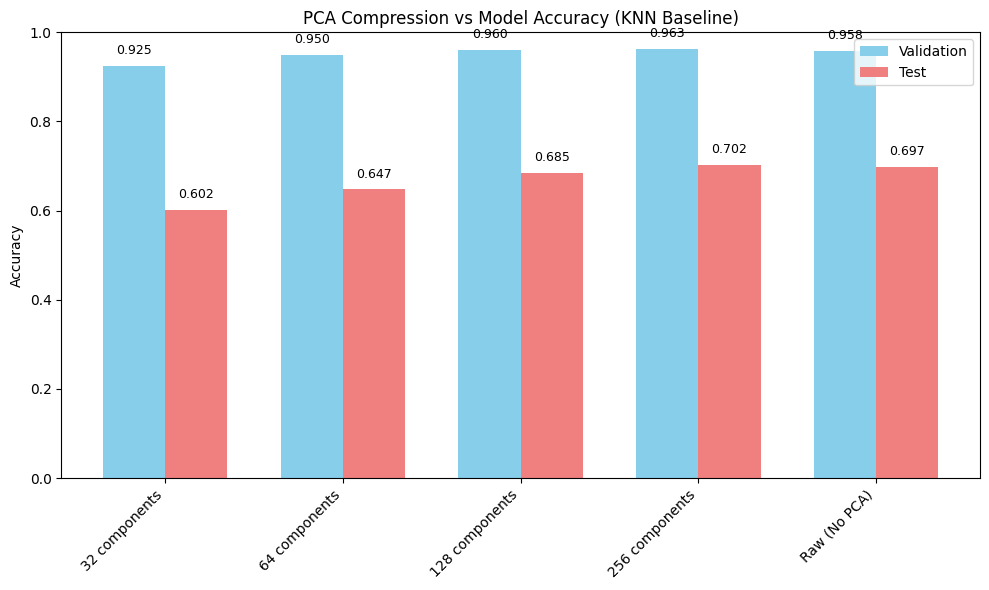

In [18]:
# PCA Accuracy Trade-off Analysis
print("\n" + "="*50)
print("PCA COMPRESSION TRADE-OFF ANALYSIS")
print("="*50)

# Test different PCA components
pca_components_list = [32, 64, 128, 256, None]  # None = no PCA
pca_results = []

X_train_split_raw, X_val_split_raw, _, _ = train_test_split(
    X_train_raw, y_train, test_size=0.2, random_state=42, stratify=y_train
)
X_test_raw_subset = X_test_raw

for n_comp in pca_components_list:
    if n_comp is None:
        # No PCA - use raw features
        X_tr = X_train_split_raw
        X_val = X_val_split_raw
        X_te = X_test_raw_subset
        comp_name = "Raw (No PCA)"
    else:
        # Apply PCA with specified components
        pca_temp = PCA(n_components=n_comp)
        X_tr = pca_temp.fit_transform(X_train_split_raw)
        X_val = pca_temp.transform(X_val_split_raw)
        X_te = pca_temp.transform(X_test_raw_subset)
        comp_name = f"{n_comp} components"
    
    # Quick test with KNN baseline
    knn_test = KNeighborsClassifier(n_neighbors=5)
    knn_test.fit(X_tr, y_train_split)
    
    val_acc = accuracy_score(y_val_split, knn_test.predict(X_val))
    test_acc = accuracy_score(y_test, knn_test.predict(X_te))
    
    pca_results.append({
        'PCA Config': comp_name,
        'Validation Accuracy': val_acc,
        'Test Accuracy': test_acc,
        'Compression': f"{n_comp if n_comp else 'None'}"
    })
    
    print(f"\n{comp_name}:")
    print(f"  Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")

pca_df = pd.DataFrame(pca_results)
print("\n" + pca_df.to_string(index=False))

# Visualize PCA trade-off
fig, ax = plt.subplots(figsize=(10, 6))
x_labels = [r['PCA Config'] for r in pca_results]
val_accs = [r['Validation Accuracy'] for r in pca_results]
test_accs = [r['Test Accuracy'] for r in pca_results]

x = np.arange(len(x_labels))
width = 0.35

ax.bar(x - width/2, val_accs, width, label='Validation', color='skyblue')
ax.bar(x + width/2, test_accs, width, label='Test', color='lightcoral')

ax.set_ylabel('Accuracy')
ax.set_title('PCA Compression vs Model Accuracy (KNN Baseline)')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1])

for i, (v_acc, t_acc) in enumerate(zip(val_accs, test_accs)):
    ax.text(i - width/2, v_acc + 0.02, f'{v_acc:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, t_acc + 0.02, f'{t_acc:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [19]:
# Naive Bayes with hyperparameter tuning
print("\n" + "-"*50)
print("NAIVE BAYES - Hyperparameter Tuning")
print("-"*50)

nb_params = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

nb_grid = GridSearchCV(GaussianNB(), nb_params, cv=5, n_jobs=-1, verbose=0, scoring='accuracy')
nb_grid.fit(X_train_split, y_train_split)

print(f"Best parameters: {nb_grid.best_params_}")
print(f"Best CV accuracy: {nb_grid.best_score_:.4f}")

models['Naive Bayes'] = nb_grid

# Validation performance
y_val_pred_nb = nb_grid.predict(X_val_split)
y_val_prob_nb = nb_grid.predict_proba(X_val_split)
val_acc_nb = accuracy_score(y_val_split, y_val_pred_nb)
val_auc_nb = roc_auc_score(y_val_split, y_val_prob_nb, multi_class='ovr')

print(f"Validation Accuracy: {val_acc_nb:.4f}")
print(f"Validation AUC-ROC: {val_auc_nb:.4f}")


--------------------------------------------------
NAIVE BAYES - Hyperparameter Tuning
--------------------------------------------------
Best parameters: {'var_smoothing': np.float64(1.873817422860383e-05)}
Best CV accuracy: 0.8440
Validation Accuracy: 0.8460
Validation AUC-ROC: 0.9948


In [ ]:
# K-Nearest Neighbors with hyperparameter tuning
print("\n" + "-"*50)
print("K-NEAREST NEIGHBORS - Hyperparameter Tuning")
print("-"*50)

knn_params = {
    'n_neighbors': np.arange(3, 11, 1),
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, n_jobs=-1, verbose=0, scoring='accuracy')
knn_grid.fit(X_train_split, y_train_split)

print(f"Best parameters: {knn_grid.best_params_}")
print(f"Best CV accuracy: {knn_grid.best_score_:.4f}")

models['KNN'] = knn_grid

# Validation performance
y_val_pred_knn = knn_grid.predict(X_val_split)
y_val_prob_knn = knn_grid.predict_proba(X_val_split)
val_acc_knn = accuracy_score(y_val_split, y_val_pred_knn)
val_auc_knn = roc_auc_score(y_val_split, y_val_prob_knn, multi_class='ovr')

print(f"Validation Accuracy: {val_acc_knn:.4f}")
print(f"Validation AUC-ROC: {val_auc_knn:.4f}")


--------------------------------------------------
K-NEAREST NEIGHBORS - Hyperparameter Tuning
--------------------------------------------------
Best parameters: {'metric': 'euclidean', 'n_neighbors': np.int64(3)}
Best CV accuracy: 0.9525
Validation Accuracy: 0.9651
Validation AUC-ROC: 0.9956


In [21]:
# Random Forest Classifier
print("\n" + "-"*50)
print("RANDOM FOREST - Training")
print("-"*50)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=1)
rf_model.fit(X_train_split, y_train_split)                            

models['Random Forest'] = rf_model

# Validation performance
y_val_pred_rf = rf_model.predict(X_val_split)
y_val_prob_rf = rf_model.predict_proba(X_val_split)
val_acc_rf = accuracy_score(y_val_split, y_val_pred_rf)
val_auc_rf = roc_auc_score(y_val_split, y_val_prob_rf, multi_class='ovr')

# Test performance
y_test_pred_rf = rf_model.predict(X_test)
y_test_prob_rf = rf_model.predict_proba(X_test)
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)
test_auc_rf = roc_auc_score(y_test, y_test_prob_rf, multi_class='ovr')

print(f"Validation Accuracy: {val_acc_rf:.4f}")
print(f"Validation AUC-ROC: {val_auc_rf:.4f}")
print(f"Test Accuracy: {test_acc_rf:.4f}")
print(f"Test AUC-ROC: {test_auc_rf:.4f}")


--------------------------------------------------
RANDOM FOREST - Training
--------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   21.7s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s


Validation Accuracy: 0.8674
Validation AUC-ROC: 0.9951
Test Accuracy: 0.7086
Test AUC-ROC: 0.9730


[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.2s finished


In [23]:
# XGBoost Classifier
print("\n" + "-"*50)
print("XGBOOST - Training")
print("-"*50)

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                          use_label_encoder=False, eval_metric='mlogloss', 
                          random_state=42, verbosity=1)
xgb_model.fit(X_train_split, y_train_split)

models['XGBoost'] = xgb_model

# Validation performance
y_val_pred_xgb = xgb_model.predict(X_val_split)
y_val_prob_xgb = xgb_model.predict_proba(X_val_split)
val_acc_xgb = accuracy_score(y_val_split, y_val_pred_xgb)
val_auc_xgb = roc_auc_score(y_val_split, y_val_prob_xgb, multi_class='ovr')

# Test performance
y_test_pred_xgb = xgb_model.predict(X_test)
y_test_prob_xgb = xgb_model.predict_proba(X_test)
test_acc_xgb = accuracy_score(y_test, y_test_pred_xgb)
test_auc_xgb = roc_auc_score(y_test, y_test_prob_xgb, multi_class='ovr')

print(f"Validation Accuracy: {val_acc_xgb:.4f}")
print(f"Validation AUC-ROC: {val_auc_xgb:.4f}")
print(f"Test Accuracy: {test_acc_xgb:.4f}")
print(f"Test AUC-ROC: {test_auc_xgb:.4f}")


--------------------------------------------------
XGBOOST - Training
--------------------------------------------------


c:\Users\aakak\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:13:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Validation Accuracy: 0.8884
Validation AUC-ROC: 0.9977
Test Accuracy: 0.7683
Test AUC-ROC: 0.9883
